# Part 2: Dynestyx — discrete-time dynamical systems

This notebook is part of the [Gentle Introduction to Dynestyx](../00_index.ipynb). We introduce **dynestyx** as an extension of NumPyro for **dynamical systems**, with a clear separation between *what* the model is and *how* we simulate or score it.

## 2.1 What is Dynestyx? Separation of concerns

**Dynestyx** extends NumPyro by giving you a standard way to **sample from a dynamical system** and to **compute (or approximate) the marginal likelihood** of observations. The key idea is **separation of concerns**:

- **What** the model is: parameters $\theta$, initial condition $p(x_0)$, state evolution (discrete or continuous time), observation model $p(y_t \mid x_t, \ldots)$. This is the `DynamicalModel`.
- **How** we simulate or score: *simulators* (e.g. `DiscreteTimeSimulator`, `SDESimulator`) unroll the dynamics and generate state/observation trajectories; *filters* (e.g. particle filter, Kalman filter) compute $p(y_{1:T} \mid \theta)$ without sampling the latent states.

You write the model once; then you choose whether to "sample the full state trajectory" (simulator) or "marginalize states and score data" (filter). Different interpretations of "sampling a dynamical system"—full trajectory vs. parameter-only inference—are handled by swapping handlers.

## 2.2 A first Dynestyx model: discrete-time stochastic volatility

We use a **discrete-time stochastic volatility** model: a latent log-variance $x_t$ follows an AR(1), and we observe noisy returns:

- $x_0 \sim \mathcal{N}(0, 1)$
- $x_{t+1} \mid x_t \sim \mathcal{N}(\phi x_t, \sigma_\eta)$ (with $\sigma_\eta$ fixed)
- $y_t \mid x_t \sim \mathcal{N}(0, e^{x_t/2})$ (observation noise scale is $e^{x_t/2}$)

The only parameter we learn is $\phi \in (0, 1)$. This is a simple **discrete-time state-space model** with a non-linear observation map.

### 2.2.1 The context variable and handlers

To generate or condition on data, dynestyx uses a **context**: a `Context` object that holds time-indexed information for *one* trajectory:

- **`observations`**: a `Trajectory` with `times` (and optionally `values` when we have data).
- **`controls`**: optional; a `Trajectory` for exogenous inputs $u_t$. We won't use controls here; to include them, you would set `controls=Trajectory(times=ctrl_times, values=ctrl_values)` and use `control_dim > 0` in the model. See the [discrete-time LTI with controls](../../deep_dives/discrete_time_lti_with_controls.ipynb) deep dive for that.

**Handlers** determine *how* the generic `dsx.sample("name", dynamics)` is interpreted:

- **`Condition(context)`**: fixes the context for the enclosed `sample` call (times, and optionally observed values and controls).
- **`DiscreteTimeSimulator()`**: when you `sample`, it *simulates* the discrete-time model step-by-step and adds the resulting states and observations as sites. So `Predictive(..., params=...)` with `DiscreteTimeSimulator()` + `Condition(context)` generates one trajectory from the model at the given times.

Handler order: typically **simulator outside, Condition inside** so that the simulator sees the context (e.g. observation times) when it runs.

### 2.2.2 Defining the model: DynamicalModel and DiscreteTimeStateEvolution

A `DynamicalModel` is built from:

- **`initial_condition`**: a NumPyro distribution $p(x_0)$.
- **`state_evolution`**: for discrete time, a **`DiscreteTimeStateEvolution`**: a callable `(x, u, t_now, t_next) \mapsto$ distribution over next state**. It returns a *distribution* over $x_{t+1}$, not a single value. (For continuous time we use `ContinuousTimeStateEvolution` with drift/diffusion; we get to that in [Part 6](../06_continuous_time.ipynb).)
- **`observation_model`**: a callable `(x, u, t) \mapsto$ distribution over $y_t$**.
- **`state_dim`**, **`observation_dim`**, **`control_dim`**: dimensions (use `control_dim=0` if no controls).

We implement the state evolution as a function `(x, u, t_now, t_next)` that returns a NumPyro distribution; here we use a closure over the sampled $\phi$.

In [1]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import jax.random as jr
import dynestyx as dsx
from dynestyx.dynamical_models import DynamicalModel

def stochastic_volatility_model():
    phi = numpyro.sample("phi", dist.Uniform(0.0, 1.0))
    sigma_eta = 0.5  # fixed vol-of-vol

    initial_condition = dist.Normal(0.0, 1.0)

    def state_evolution(x, u, t_now, t_next):
        return dist.Normal(phi * x, sigma_eta)

    def observation_model(x, u, t):
        return dist.Normal(0.0, jnp.exp(x / 2.0))  # scale = exp(x/2)

    dynamics = DynamicalModel(
        state_dim=1,
        observation_dim=1,
        control_dim=0,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )
    return dsx.sample("f", dynamics)

### 2.2.3 Generating data with Predictive and DiscreteTimeSimulator

We set up a **context** with observation times (no values yet), then run `Predictive` with **`DiscreteTimeSimulator()`** and **`Condition(context)`**. The simulator unrolls the dynamics at those times and produces `states` and `observations`. We generate data *from the model* the same way we did for linear regression—but now the generative process is a dynamical system.

In [2]:
from numpyro.infer import Predictive
from dynestyx.simulators import DiscreteTimeSimulator
from dynestyx.ops import Context, Trajectory
from dynestyx.handlers import Condition

key = jr.PRNGKey(0)
phi_true = 0.9
obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
context = Context(observations=Trajectory(times=obs_times), controls=Trajectory())

predictive = Predictive(
    stochastic_volatility_model,
    params={"phi": jnp.array(phi_true)},
    num_samples=1,
    exclude_deterministic=False,
)
with DiscreteTimeSimulator():
    with Condition(context):
        synthetic = predictive(key)

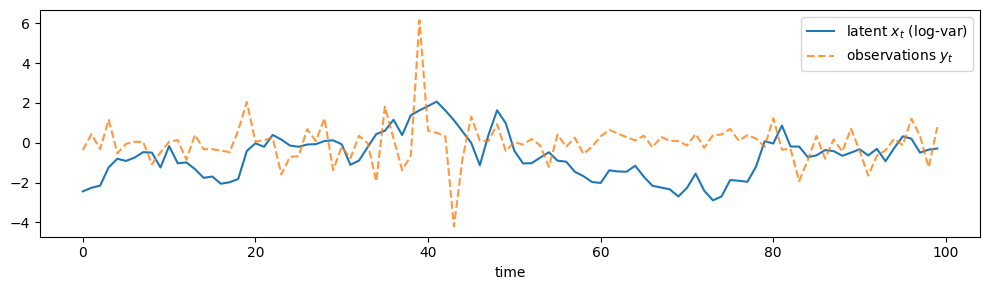

In [3]:
import matplotlib.pyplot as plt

obs_values = synthetic["observations"][0]
states = synthetic["states"][0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(obs_times, states, label="latent $x_t$ (log-var)")
ax.plot(obs_times, obs_values, label="observations $y_t$", alpha=0.8, linestyle="--")
ax.legend()
ax.set_xlabel("time")
plt.tight_layout()
plt.show()

## 2.3 Inference: NUTS + DiscreteTime Simulator

To infer **both** the latent states $x_{1:T}$ and the parameter $\phi$ from data, we **condition on the observations** by passing them in the context, and use the **same** `DiscreteTimeSimulator` + `Condition`. The model then has observed sites for $y_t$; NUTS samples $\phi$ and the full state trajectory $x_{0:T}$. So we get $p(x, \theta \mid \text{data})$ via MCMC.

In [4]:
from numpyro.infer import MCMC, NUTS

observation_trajectory = Trajectory(times=obs_times, values=obs_values)

def data_conditioned_model():
    context = Context(
        observations=observation_trajectory,
        controls=Trajectory(),
    )
    with DiscreteTimeSimulator():
        with Condition(context):
            return stochastic_volatility_model()

nuts_kernel = NUTS(data_conditioned_model)
mcmc = MCMC(nuts_kernel, num_warmup=200, num_samples=200)
mcmc.run(jr.PRNGKey(1))
posterior_sv = mcmc.get_samples()
print("Posterior phi mean:", float(jnp.mean(posterior_sv["phi"])))
print("True phi:", phi_true)

sample: 100%|██████████| 400/400 [00:00<00:00, 846.13it/s, 15 steps of size 2.42e-01. acc. prob=0.87] 

Posterior phi mean: 0.9077998399734497
True phi: 0.9


**Next:** [Part 3 — Filtering and the marginal log-likelihood](../03_filtering_mll.ipynb)